In [ ]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn torch torchvision joblib requests -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import joblib
import requests
import warnings
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
ticker = "AAPL"

df = yf.download(ticker, start="2015-01-01", end="2024-12-31", auto_adjust=True)
spy = yf.download("SPY", start="2015-01-01", end="2024-12-31")
vix = yf.download("^VIX", start="2015-01-01", end="2024-12-31")

# Fix MultiIndex
for d in [df, spy, vix]:
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
data = df.copy()

data["SPY_Close"] = spy["Close"]
data["SPY_Return"] = data["SPY_Close"].pct_change()

data["VIX"] = vix["Close"]
data["VIX_Change"] = data["VIX"].pct_change()

In [ ]:
API_KEY = "29c9b60f2b124eaf8325e9dd5175eb39"

def get_news_sentiment():
    url = f"https://newsapi.org/v2/everything?q=AAPL&language=en&apiKey={API_KEY}"
    res = requests.get(url).json()

    sentiments = []
    for article in res.get("articles", []):
        text = article["title"] or ""
        text = text.lower()

        # simple rule-based sentiment
        if any(word in text for word in ["gain", "growth", "profit", "surge"]):
            sentiments.append(1)
        elif any(word in text for word in ["loss", "drop", "fall", "decline"]):
            sentiments.append(-1)
        else:
            sentiments.append(0)

    if len(sentiments) == 0:
        return 0

    return np.mean(sentiments)

# Apply daily sentiment (simple approximation)
sentiment_score = get_news_sentiment()
data["News_Sentiment"] = sentiment_score

In [ ]:
# Moving averages
data["SMA_10"] = data["Close"].rolling(10).mean()
data["SMA_20"] = data["Close"].rolling(20).mean()
data["SMA_50"] = data["Close"].rolling(50).mean()

# EMA
data["EMA_12"] = data["Close"].ewm(span=12).mean()
data["EMA_26"] = data["Close"].ewm(span=26).mean()

# MACD
data["MACD"] = data["EMA_12"] - data["EMA_26"]
data["MACD_Signal"] = data["MACD"].ewm(span=9).mean()

# RSI
delta = data["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
data["RSI"] = 100 - (100 / (1 + rs))

# Volatility
data["Volatility"] = data["Close"].pct_change().rolling(20).std()

# Advanced features
data["Z_Close"] = (data["Close"] - data["Close"].rolling(20).mean()) / data["Close"].rolling(20).std()
data["Volume_Ratio"] = data["Volume"] / data["Volume"].rolling(20).mean()
data["Trend_Strength"] = data["SMA_10"] - data["SMA_50"]

# Target (RETURN)
data["Target_Return"] = data["Close"].pct_change().shift(-1)

data.dropna(inplace=True)

In [ ]:
FEATURES = [
    "Close", "Volume",
    "SMA_10", "SMA_20", "SMA_50",
    "EMA_12", "EMA_26",
    "MACD", "MACD_Signal",
    "RSI", "Volatility",
    "Z_Close", "Volume_Ratio", "Trend_Strength",
    "SPY_Return", "VIX", "VIX_Change",
    "News_Sentiment"
]

TARGET = "Target_Return"

In [ ]:
feature_data = data[FEATURES].values
target_data = data[TARGET].values

n = len(data)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train = feature_data[:train_end]
y_train = target_data[:train_end]

X_val = feature_data[train_end:val_end]
y_val = target_data[train_end:val_end]

X_test = feature_data[val_end:]
y_test = target_data[val_end:]

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
target_scaler = MinMaxScaler()
y_train = target_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_val   = target_scaler.transform(y_val.reshape(-1,1)).flatten()
y_test  = target_scaler.transform(y_test.reshape(-1,1)).flatten()

In [ ]:
WINDOW = 60

def create_sequences(X, y):
    Xs, ys = [], []
    for i in range(len(X) - WINDOW):
        Xs.append(X[i:i+WINDOW])
        ys.append(y[i+WINDOW])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train, y_train)
X_val, y_val = create_sequences(X_val, y_val)
X_test, y_test = create_sequences(X_test, y_test)

In [ ]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(StockDataset(X_val, y_val), batch_size=64)

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 128, 3, batch_first=True)
        self.attn = nn.Linear(128, 1)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        weights = torch.softmax(self.attn(out), dim=1)
        context = torch.sum(weights * out, dim=1)
        return self.fc(context)

model = LSTMModel(len(FEATURES)).to(device)

In [ ]:
class HybridLoss(nn.Module):
    def forward(self, pred, target):
        mse = torch.mean((pred - target) ** 2)

        # safe denominator
        denom = torch.clamp(torch.abs(target), min=1e-3)
        mape = torch.mean(torch.abs((target - pred) / denom))

        return 0.8 * mse + 0.2 * mape

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [ ]:
for epoch in range(20):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

Epoch 1 Loss: 118065.8596
Epoch 2 Loss: 245656.2084
Epoch 3 Loss: 242742.1285
Epoch 4 Loss: 240444.8177
Epoch 5 Loss: 238203.1446
Epoch 6 Loss: 238438.5199
Epoch 7 Loss: 245617.1854
Epoch 8 Loss: 242332.1967
Epoch 9 Loss: 243074.7776
Epoch 10 Loss: 245810.1175
Epoch 11 Loss: 244160.4510
Epoch 12 Loss: 232783.1507
Epoch 13 Loss: 243235.6252
Epoch 14 Loss: 228507.7955
Epoch 15 Loss: 242964.2920
Epoch 16 Loss: 244720.8030
Epoch 17 Loss: 237244.4670
Epoch 18 Loss: 241215.0041
Epoch 19 Loss: 243264.3619
Epoch 20 Loss: 242533.9192


In [ ]:
# Cell 12 — Balanced training config
LEARNING_RATE = 0.001    # back to original — worked well
BATCH_SIZE    = 64       # back to original
EPOCHS        = 100
PATIENCE      = 20

# Recreate loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# ── Back to MSELoss — better for stock regression ─────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ── ReduceLROnPlateau — only reduce LR when val stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = "min",
    factor   = 0.5,      # halve the LR
    patience = 8,        # wait 8 epochs before reducing
    min_lr   = 1e-6
)

best_val_loss  = float("inf")
patience_count = 0
train_losses   = []
val_losses     = []
lr_history     = []

print("Starting training (balanced config)...\n")

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            val_loss += criterion(model(X_batch), y_batch).item()

    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    lr_history.append(current_lr)

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        patience_count = 0
        torch.save({
            "epoch":                epoch,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":             avg_val,
            "features":             FEATURES
        }, "best_model.pth")
        status = "✅ saved"
    else:
        patience_count += 1
        status = f"patience {patience_count}/{PATIENCE}"

    if epoch % 5 == 0 or patience_count == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train: {avg_train:.6f} | "
              f"Val: {avg_val:.6f} | "
              f"LR: {current_lr:.7f} | {status}")

    if patience_count >= PATIENCE:
        print(f"\n⏹ Early stopping at epoch {epoch}")
        break

print(f"\nBest val loss: {best_val_loss:.6f}")

Starting training (balanced config)...

Epoch   1/100 | Train: 0.028439 | Val: 0.472470 | LR: 0.0010000 | ✅ saved
Epoch   2/100 | Train: 0.009899 | Val: 0.324385 | LR: 0.0010000 | ✅ saved
Epoch   3/100 | Train: 0.007702 | Val: 0.019173 | LR: 0.0010000 | ✅ saved
Epoch   5/100 | Train: 0.007274 | Val: 0.072711 | LR: 0.0010000 | patience 2/20
Epoch   6/100 | Train: 0.015857 | Val: 0.001312 | LR: 0.0010000 | ✅ saved
Epoch   9/100 | Train: 0.006102 | Val: 0.001069 | LR: 0.0010000 | ✅ saved
Epoch  10/100 | Train: 0.005342 | Val: 0.001356 | LR: 0.0010000 | patience 1/20
Epoch  13/100 | Train: 0.003980 | Val: 0.001034 | LR: 0.0010000 | ✅ saved
Epoch  15/100 | Train: 0.007213 | Val: 0.001449 | LR: 0.0010000 | patience 2/20
Epoch  16/100 | Train: 0.003761 | Val: 0.001012 | LR: 0.0010000 | ✅ saved
Epoch  18/100 | Train: 0.003760 | Val: 0.000980 | LR: 0.0010000 | ✅ saved
Epoch  20/100 | Train: 0.009172 | Val: 0.008490 | LR: 0.0010000 | patience 2/20
Epoch  25/100 | Train: 0.005155 | Val: 0.001134 

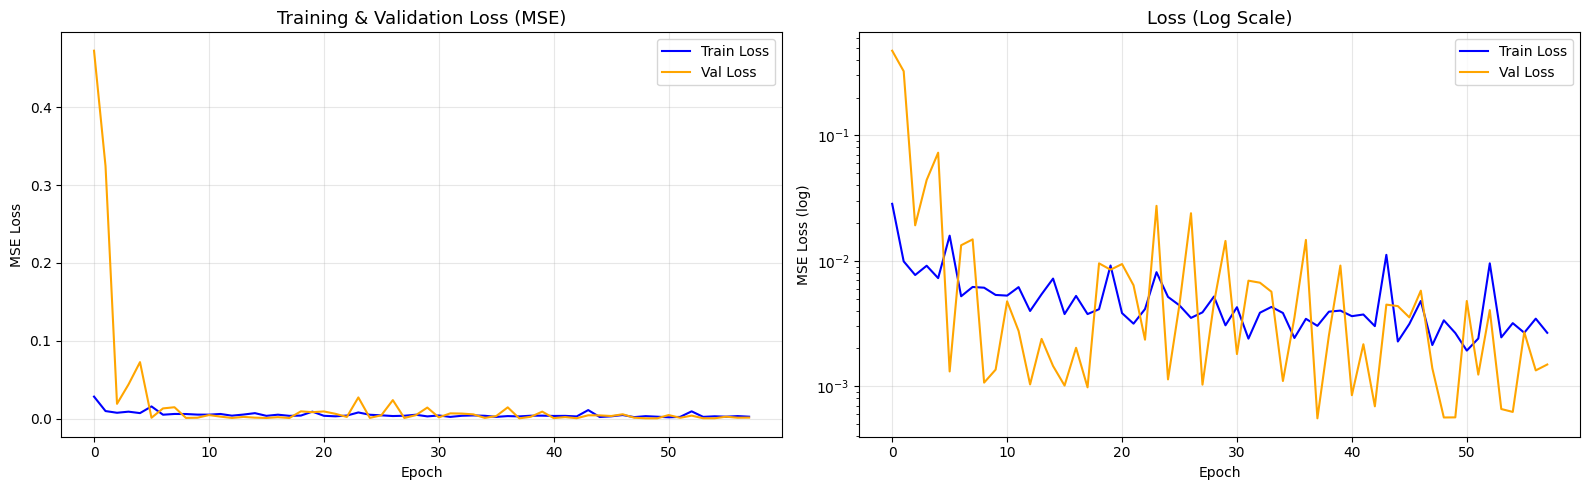

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  Loss curves
axes[0].plot(train_losses, label="Train Loss", color="blue")
axes[0].plot(val_losses,   label="Val Loss",   color="orange")
axes[0].set_title("Training & Validation Loss (MSE)", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#  Log scale for better visibility
axes[1].semilogy(train_losses, label="Train Loss", color="blue")
axes[1].semilogy(val_losses,   label="Val Loss",   color="orange")
axes[1].set_title("Loss (Log Scale)", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss (log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [ ]:
# Load best model
checkpoint = torch.load("best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

#  Collect all predictions
all_preds, all_actuals = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).cpu().numpy()
        all_preds.extend(preds.flatten())
        all_actuals.extend(y_batch.numpy().flatten())

all_preds   = np.array(all_preds)
all_actuals = np.array(all_actuals)

#  Inverse transform to real dollar values
preds_real   = target_scaler.inverse_transform(
                   all_preds.reshape(-1, 1)).flatten()
actuals_real = target_scaler.inverse_transform(
                   all_actuals.reshape(-1, 1)).flatten()

#  Metrics
rmse = np.sqrt(mean_squared_error(actuals_real, preds_real))
mae  = mean_absolute_error(actuals_real, preds_real)
mape = np.mean(np.abs((actuals_real - preds_real) / actuals_real)) * 100
r2   = 1 - np.sum((actuals_real - preds_real)**2) / \
           np.sum((actuals_real - np.mean(actuals_real))**2)

print("=" * 45)
print("        TEST SET EVALUATION RESULTS")
print("=" * 45)
print(f"  RMSE : ${rmse:.2f}  (avg dollar error squared)")
print(f"  MAE  : ${mae:.2f}  (avg dollar error)")
print(f"  MAPE : {mape:.2f}%   (avg % error)")
print(f"  R²   : {r2:.4f}  (1.0 = perfect)")
print("=" * 45)

        TEST SET EVALUATION RESULTS
  RMSE : $10.30  (avg dollar error squared)
  MAE  : $8.19  (avg dollar error)
  MAPE : 3.82%   (avg % error)
  R²   : 0.8272  (1.0 = perfect)


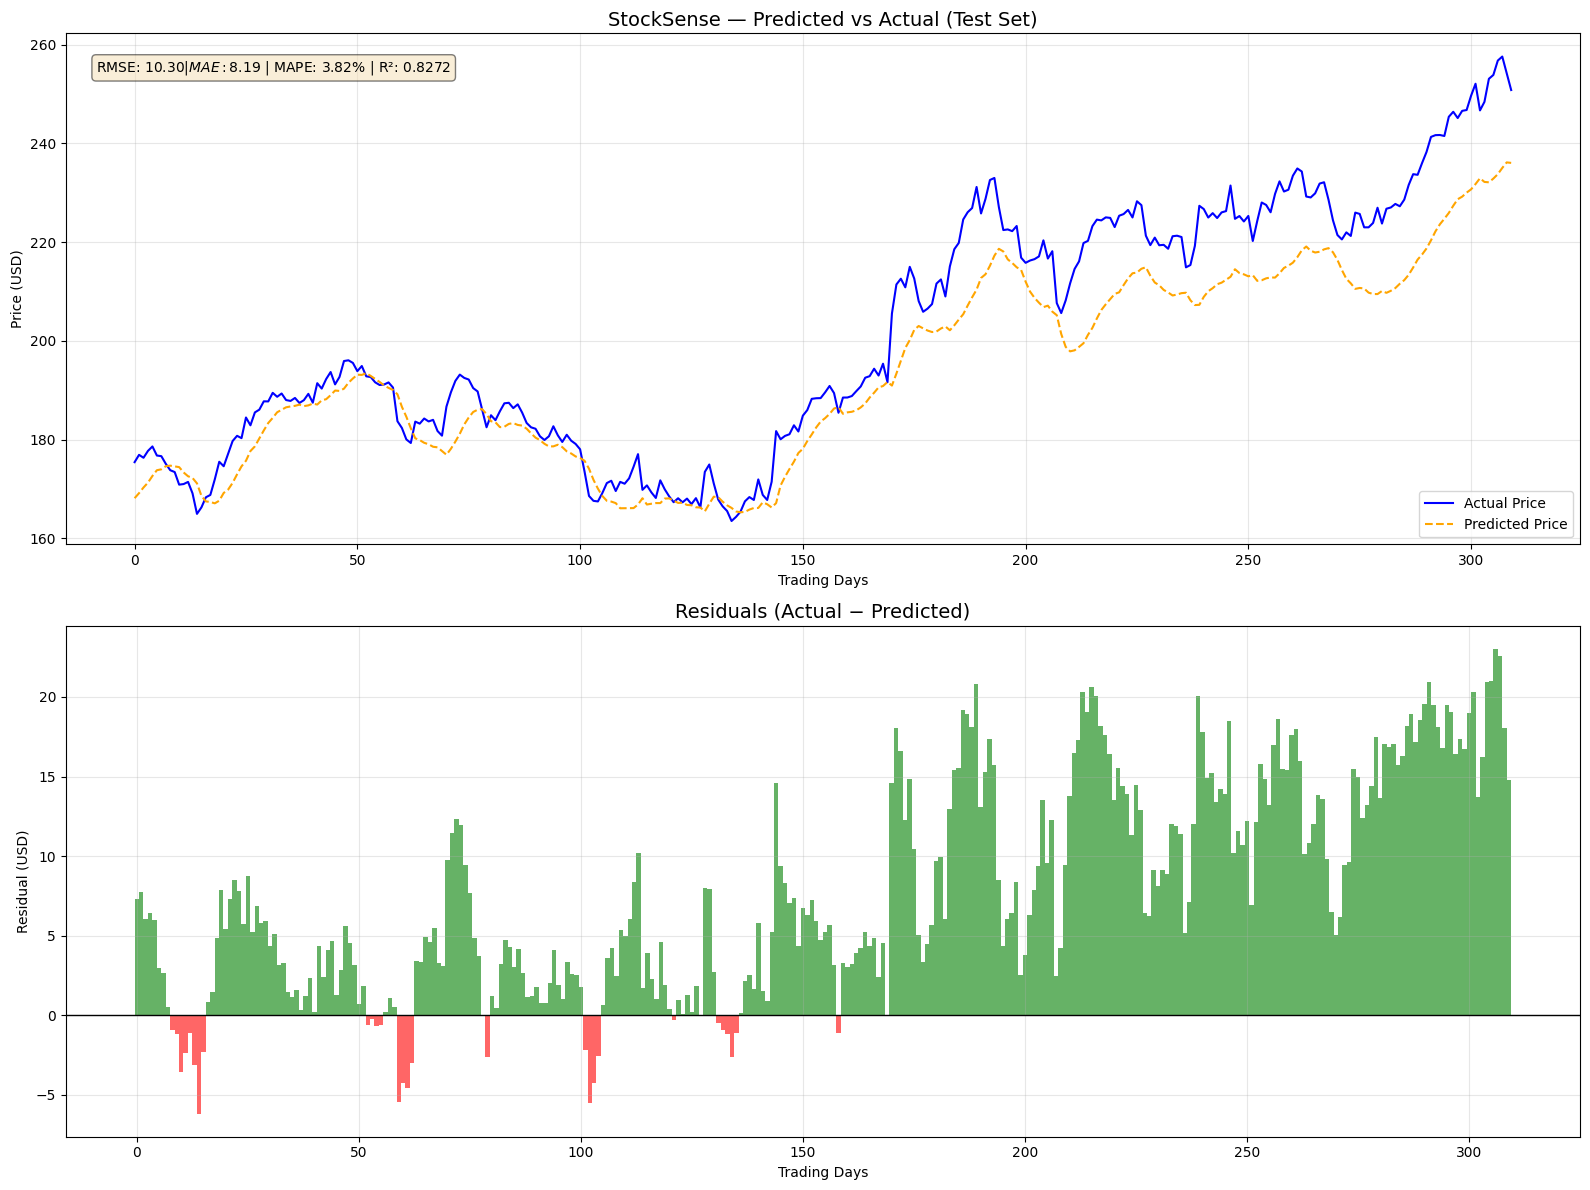

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

#  Full test period
axes[0].plot(actuals_real, label="Actual Price",    color="blue",   linewidth=1.5)
axes[0].plot(preds_real,   label="Predicted Price", color="orange",
             linewidth=1.5, linestyle="--")
axes[0].set_title("StockSense — Predicted vs Actual (Test Set)", fontsize=14)
axes[0].set_xlabel("Trading Days")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Annotate metrics
axes[0].text(0.02, 0.95,
             f"RMSE: ${rmse:.2f} | MAE: ${mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f}",
             transform=axes[0].transAxes, fontsize=10,
             verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

#  Residual plot
residuals = actuals_real - preds_real
axes[1].bar(range(len(residuals)), residuals,
            color=["green" if r > 0 else "red" for r in residuals],
            alpha=0.6, width=1)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals (Actual − Predicted)", fontsize=14)
axes[1].set_xlabel("Trading Days")
axes[1].set_ylabel("Residual (USD)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("predictions_chart.png", dpi=150)
plt.show()

In [ ]:
import shutil, os

# Save all artefacts
joblib.dump(feature_scaler, "feature_scaler.pkl")
joblib.dump(target_scaler,  "target_scaler.pkl")

# Save feature list
import json
with open("features.json", "w") as f:
    json.dump(FEATURES, f)

# Zip everything
os.makedirs("stocksense_model", exist_ok=True)
for f in ["best_model.pth", "feature_scaler.pkl",
          "target_scaler.pkl", "features.json",
          "training_curves.png", "predictions_chart.png",
          "raw_data_exploration.png", "technical_indicators.png",
          "correlation_heatmap.png"]:
    if os.path.exists(f):
        shutil.copy(f, f"stocksense_model/{f}")

shutil.make_archive("stocksense_model", "zip", "stocksense_model")
print("✅ All artefacts saved to stocksense_model.zip")

# Download from Colab
from google.colab import files
files.download("stocksense_model.zip")

✅ All artefacts saved to stocksense_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>